In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# rdkit
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.molSize = 500,430

from mol_functions import ToSubstructures, DrawMols, ClusterMols
from analysis_functions import CoProcessor
import utils

# Getting the data set of molecules 

In [3]:
data = pd.read_excel('data.xlsx')
smileses = data.SMILES.dropna().reset_index(drop=True)

# Background on the molecules:

In the data.xlsx file we have 88 conjuigated polymer (CP) repeating units. CPs typically have a comb-like structure with a rigid main chain (rich in aromatic rings) and alkyl side chains. Some examples are shown below:

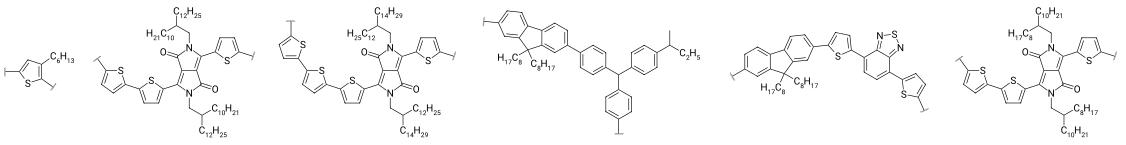

In [4]:
# Chem.MolFromSmiles(smileses[5])
dm = DrawMols(ppi=100)
examples = [Chem.MolFromSmiles(smi) for smi in smileses.sample(6, random_state=0)]
dm.show_mol_row(examples)

The repeating unit's dangling bond ends are marked by the squiggly line e.g.

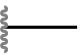

In [5]:
dm = DrawMols(ppi=500)
dm.show_mol(Chem.MolFromSmiles('C*'))

# Objective:

The objective of this script is to sort a dataset of 88 conjugated polymer (CP) repeating units according to their repeat unit structures. A hierarchical clustering algorithm will be applied to arrange the 2D structures, with priority given to grouping similar main-chain structures.

A simple illustrative example of hierarchical clustering, applied to the organisation of different cars, is shown below:


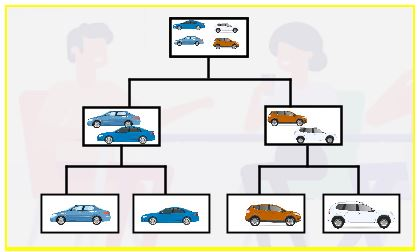

(Figure taken from https://www.simplilearn.com/tutorials/data-science-tutorial/hierarchical-clustering-in-r)

In this example, the cars are first split at a relatively large distance threshold, producing coarse-grained clusters that separate them by broad similarities (e.g., colour). These clusters are then subdivided at smaller distance thresholds to capture finer distinctions. The final level of the hierarchy yields the sorted arrangement of cars.

## Converting the set of SMILES to RDKit mol objects
The CoProcessor.transform method works like the pandas '.apply', however it is designed for more general inputs and uses memoisation for faster computation.

In [6]:
cp = CoProcessor(smileses)
mols = cp.transform(lambda x : Chem.MolFromSmiles(x))

We now have a tuple of mol objects that are stored in cp.cos. From here we want to split each mol object into fragments that separate out the main chain and side chain components of the structures

In [7]:
cp.cos = list(cp.cos)

In [8]:
frags = cp.split(lambda x : ToSubstructures(x).get_substructures(break_mainchain_bonds=False, break_sidechain_bonds=True, clean_up_dummies=True))

In [9]:
# frags[6][2]

Extracting first fragment from all split mols which corresponds to the main chain component (based on the workings of ToSubstructures())

In [10]:
mainchains = cp.interact(lambda x : x[0])

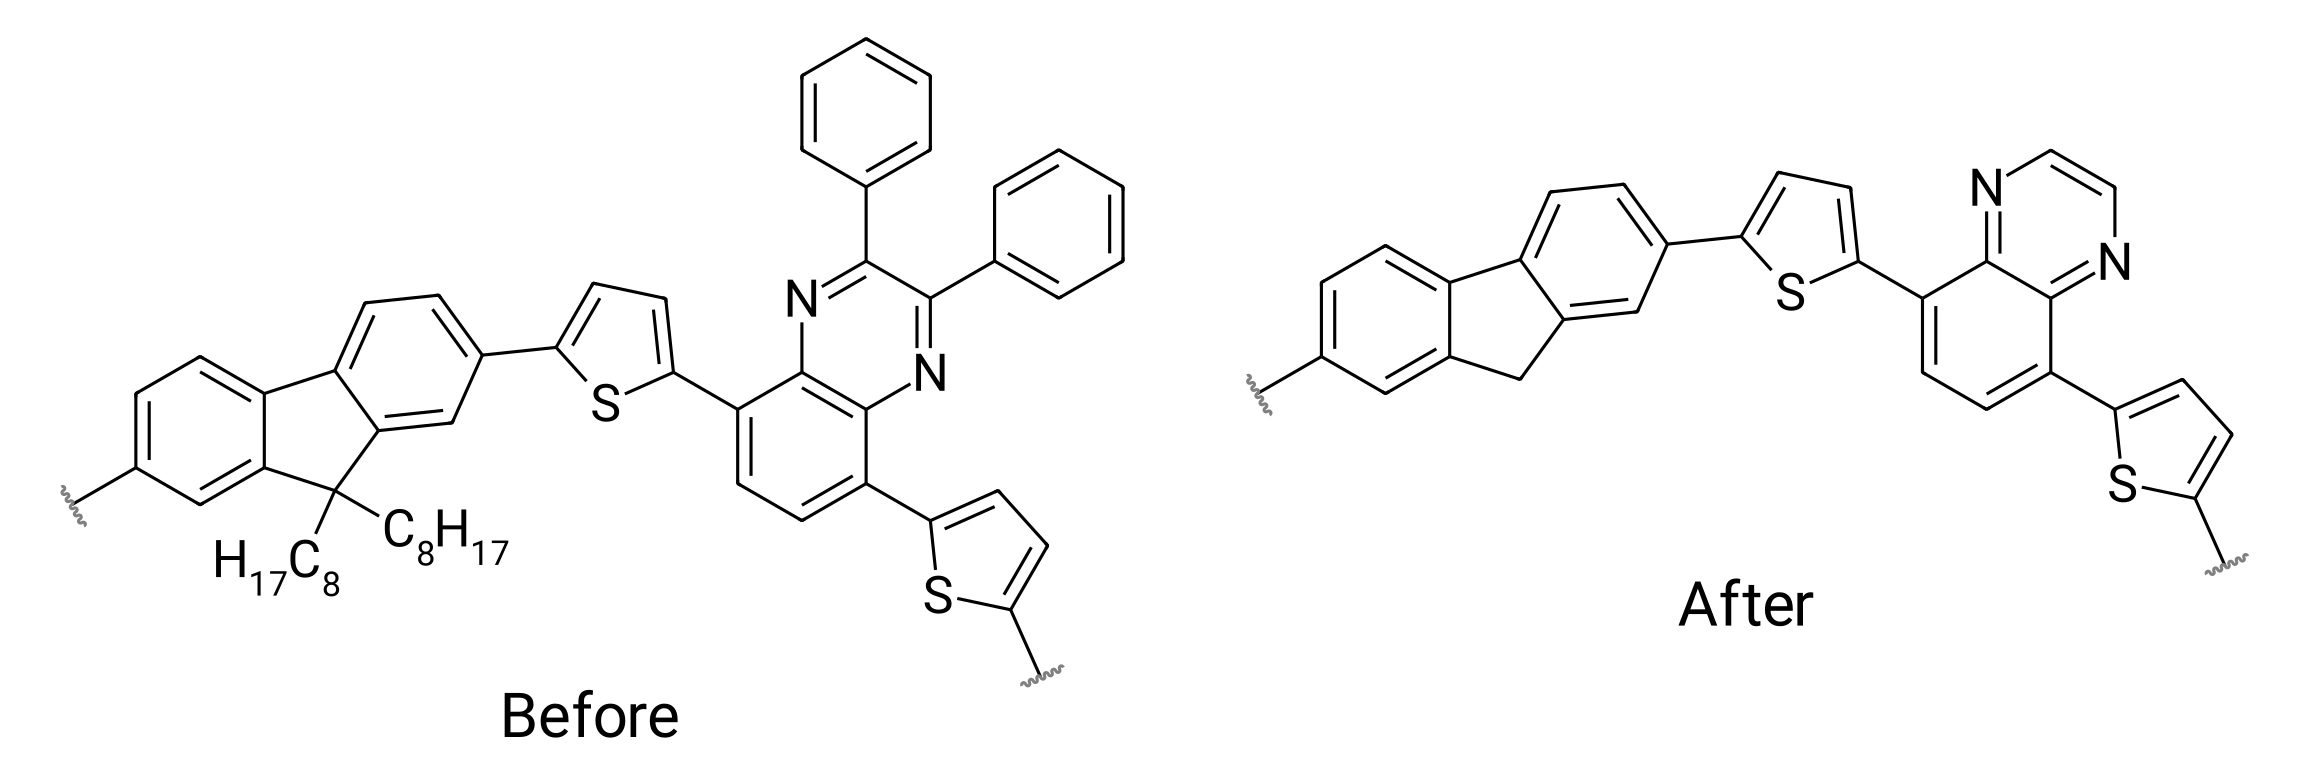

In [12]:
i = 14 # change this for more examples of the structure transformation
dm.show_mol_row([mols[i], mainchains[i]], legend=['Before', 'After'])

# Checking the best fingerprinting size (ECFP) to represent all the main chain structures

In [13]:
cm = ClusterMols(mainchains)
x,y = cm.optimize_fps(radius=5, return_xy=True)
print(cm.gen_kwargs)

Maximizing fingerprint size: 100%|█████████████████████████████████████████████████████| 20/20 [01:21<00:00,  4.07s/it]

Reached maximum iterations. Stopping.
Updated fingerprints.
{'fpSize': 262144, 'radius': 5}


Text(0, 0.5, 'Total non-zero bits')

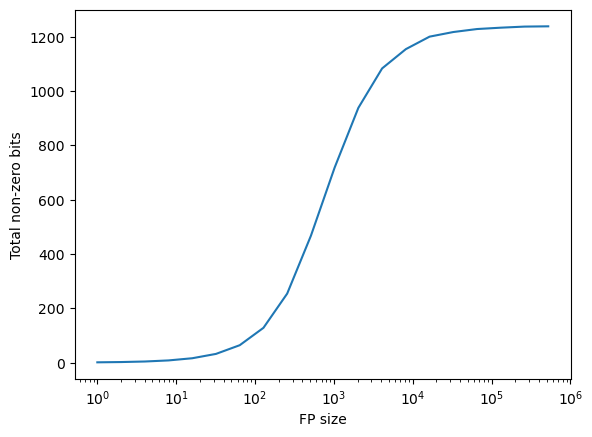

In [14]:
plt.semilogx(x,y)
plt.xlabel('FP size')
plt.ylabel('Total non-zero bits')

Can see that the total number of non-zero bits plateus between 10^5-10^6. Thus, will not get many bit collisions operating in this range of fingerprint size (at a radius of 5).

# Applying the full clustering algorithm:
So far, have deomstrated some key parts of the of the clustering algorithm. Now applying it to the data set.

In [15]:
def hcluster(arr, clustering_method, depth=0, max_depth=3, clustering_args=None):

    """
    Performs hierarical clustering for a given clustering method and array
    
    Example useage
    --------------

    def cluster_halves(arr):
        mid = len(arr) // 2
        left_half = arr[:mid]
        right_half = arr[mid:]
        clusters = [left_half, right_half]
        return clusters

    def cluster_thirds(arr):
        third = len(arr) // 3
        left = arr[:third]
        middle = arr[third:-third:]
        right = arr[-third:]
        clusters = [left, middle, right]
        return clusters

    arr = [1, 2, 3, 4, 5, 6, 7, 8, 9]
    result = hcluster(arr, cluster_halves, max_depth=2)
    print("Result:", result)
    result = hcluster(arr, cluster_thirds, max_depth=1)
    print("Result:", result)

    """

    
    # Base conditions: stop if the array has 1 or fewer elements or max depth is reached
    if len(arr) <= 1 or depth >= max_depth:
        return arr
        
    current_args = clustering_args.get(depth, {}) if clustering_args else {}
    # Print the current depth and the length of the array
    # print(f"Depth: {depth}, Array length: {len(arr)}, Clustering args used: {current_args}")
    
    clusters = clustering_method(arr, **current_args)
    # Recursively apply the function to each cluster with incremented depth
    return [hcluster(cluster, clustering_method, depth + 1, max_depth, clustering_args) for cluster in clusters]

In [16]:
def cluster_by_mc_substructure(keymols, fpSize, radius, distThresh):
    """
    Method requires mols to contain two dummy atoms so it can find the main chain atoms
    
    Args
    ----
    keymols : List of tuples, each containing the key and mol object (key, mol)
    """
    mols_mc = [ToSubstructures(mol).get_substructures(break_mainchain_bonds=False, break_sidechain_bonds=True, clean_up_dummies=True)[0] for _, mol in keymols]
    cm = ClusterMols(mols_mc)
    cm.set_fps(fpSize=fpSize, radius=radius)
    ckeymols = cm.cluster_mols(distThresh=distThresh, keymols=keymols)
    return ckeymols

    
def mol_hcluster(keymols, max_depth=1, clustering_method=cluster_by_mc_substructure, clustering_args=None):
    """
    Generic function that performs hierarchcial clustering on mols
    
    Args
    ----
    keymols : List of tuples, each containing the key and mol object (key, mol)

    Example
    -------
    
    clustering_args = {
        0: {"fpSize": 2**18, "radius" : 4, "distThresh" : 0.9}, # To split at depth 0
        1: {"fpSize": 2**18, "radius" : 4, "distThresh" : 0.7},  # Depth 1
        2: {"fpSize": 2**18, "radius" : 4, "distThresh" : 0.5},  # Depth 2
        3: {"fpSize": 2**18, "radius" : 5, "distThresh" : 0.2},  # Depth 3
        4: {"fpSize": 2**18, "radius" : 5, "distThresh" : 0},  # Depth 4
    }
    ckeymols = mol_hcluster(keymols, max_depth=5, clustering_args=clustering_args)
    """
    if len(clustering_args) != max_depth:
        raise ValueError("clustering_args does not match max_depth")
        
    cmols = hcluster(keymols, max_depth=max_depth, clustering_method=clustering_method, clustering_args=clustering_args)
    return cmols

Butina clustering is applied to separate the main-chain structures into clusters at each hierarchical level. The structures are first converted into molecular fingerprints (ECFP), and the Tanimoto distance is then used to quantify the dissimilarity between clusters.

In [ ]:
clustering_args = {
    0: {"fpSize": 2**18, "radius" : 4, "distThresh" : 0.9}, # To split at depth 0
    1: {"fpSize": 2**18, "radius" : 4, "distThresh" : 0.7},  # Depth 1
    2: {"fpSize": 2**18, "radius" : 4, "distThresh" : 0.5},  # Depth 2
    3: {"fpSize": 2**18, "radius" : 5, "distThresh" : 0.2},  # Depth 3
    4: {"fpSize": 2**18, "radius" : 5, "distThresh" : 0},  # Depth 4
}

In [136]:
keymols = [(key, mol) for key, mol in zip(smileses.index.tolist(), mols)] # Keeps a record of the index in each mol
ckeymols = mol_hcluster(keymols, max_depth=5, clustering_args=clustering_args)

In [140]:
lowest_ckeymols = utils.to_lowest_level(ckeymols)

Within each of the lowest level clusters (Depth 4), the distance threshold was 0 meaning these lowest level clusters should have the same main chain structure (but differ in side chains) 

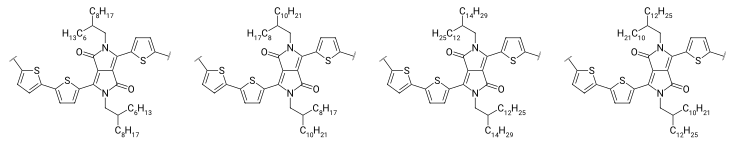

In [ ]:
dm = DrawMols(ppi=100)
lowest_cmols = utils.extract(lowest_ckeymols, index=1)
dm.show_mol_row(lowest_cmols[2])

# Sorting the side chains by their molar mass

In [146]:
mass_sorted_lowest_ckeymols = [
    sorted(subgroup, key=lambda x: rdMolDescriptors.CalcExactMolWt(x[1]), reverse=False) for subgroup in lowest_ckeymols
]

# Flattening the nested list and showing the resulting organised structures

In [ ]:
flat_ckeymols = flatten(mass_sorted_lowest_ckeymols)
flat_ckey = extract(flat_ckeymols, index=0)
flat_cmols = extract(flat_ckeymols, index=1)

In [150]:
dm = DrawMols(ppi=100)

img = dm.show_mol_grid(
    nest_the_list(
        flat_cmols
    , n_cols=8
    )
)

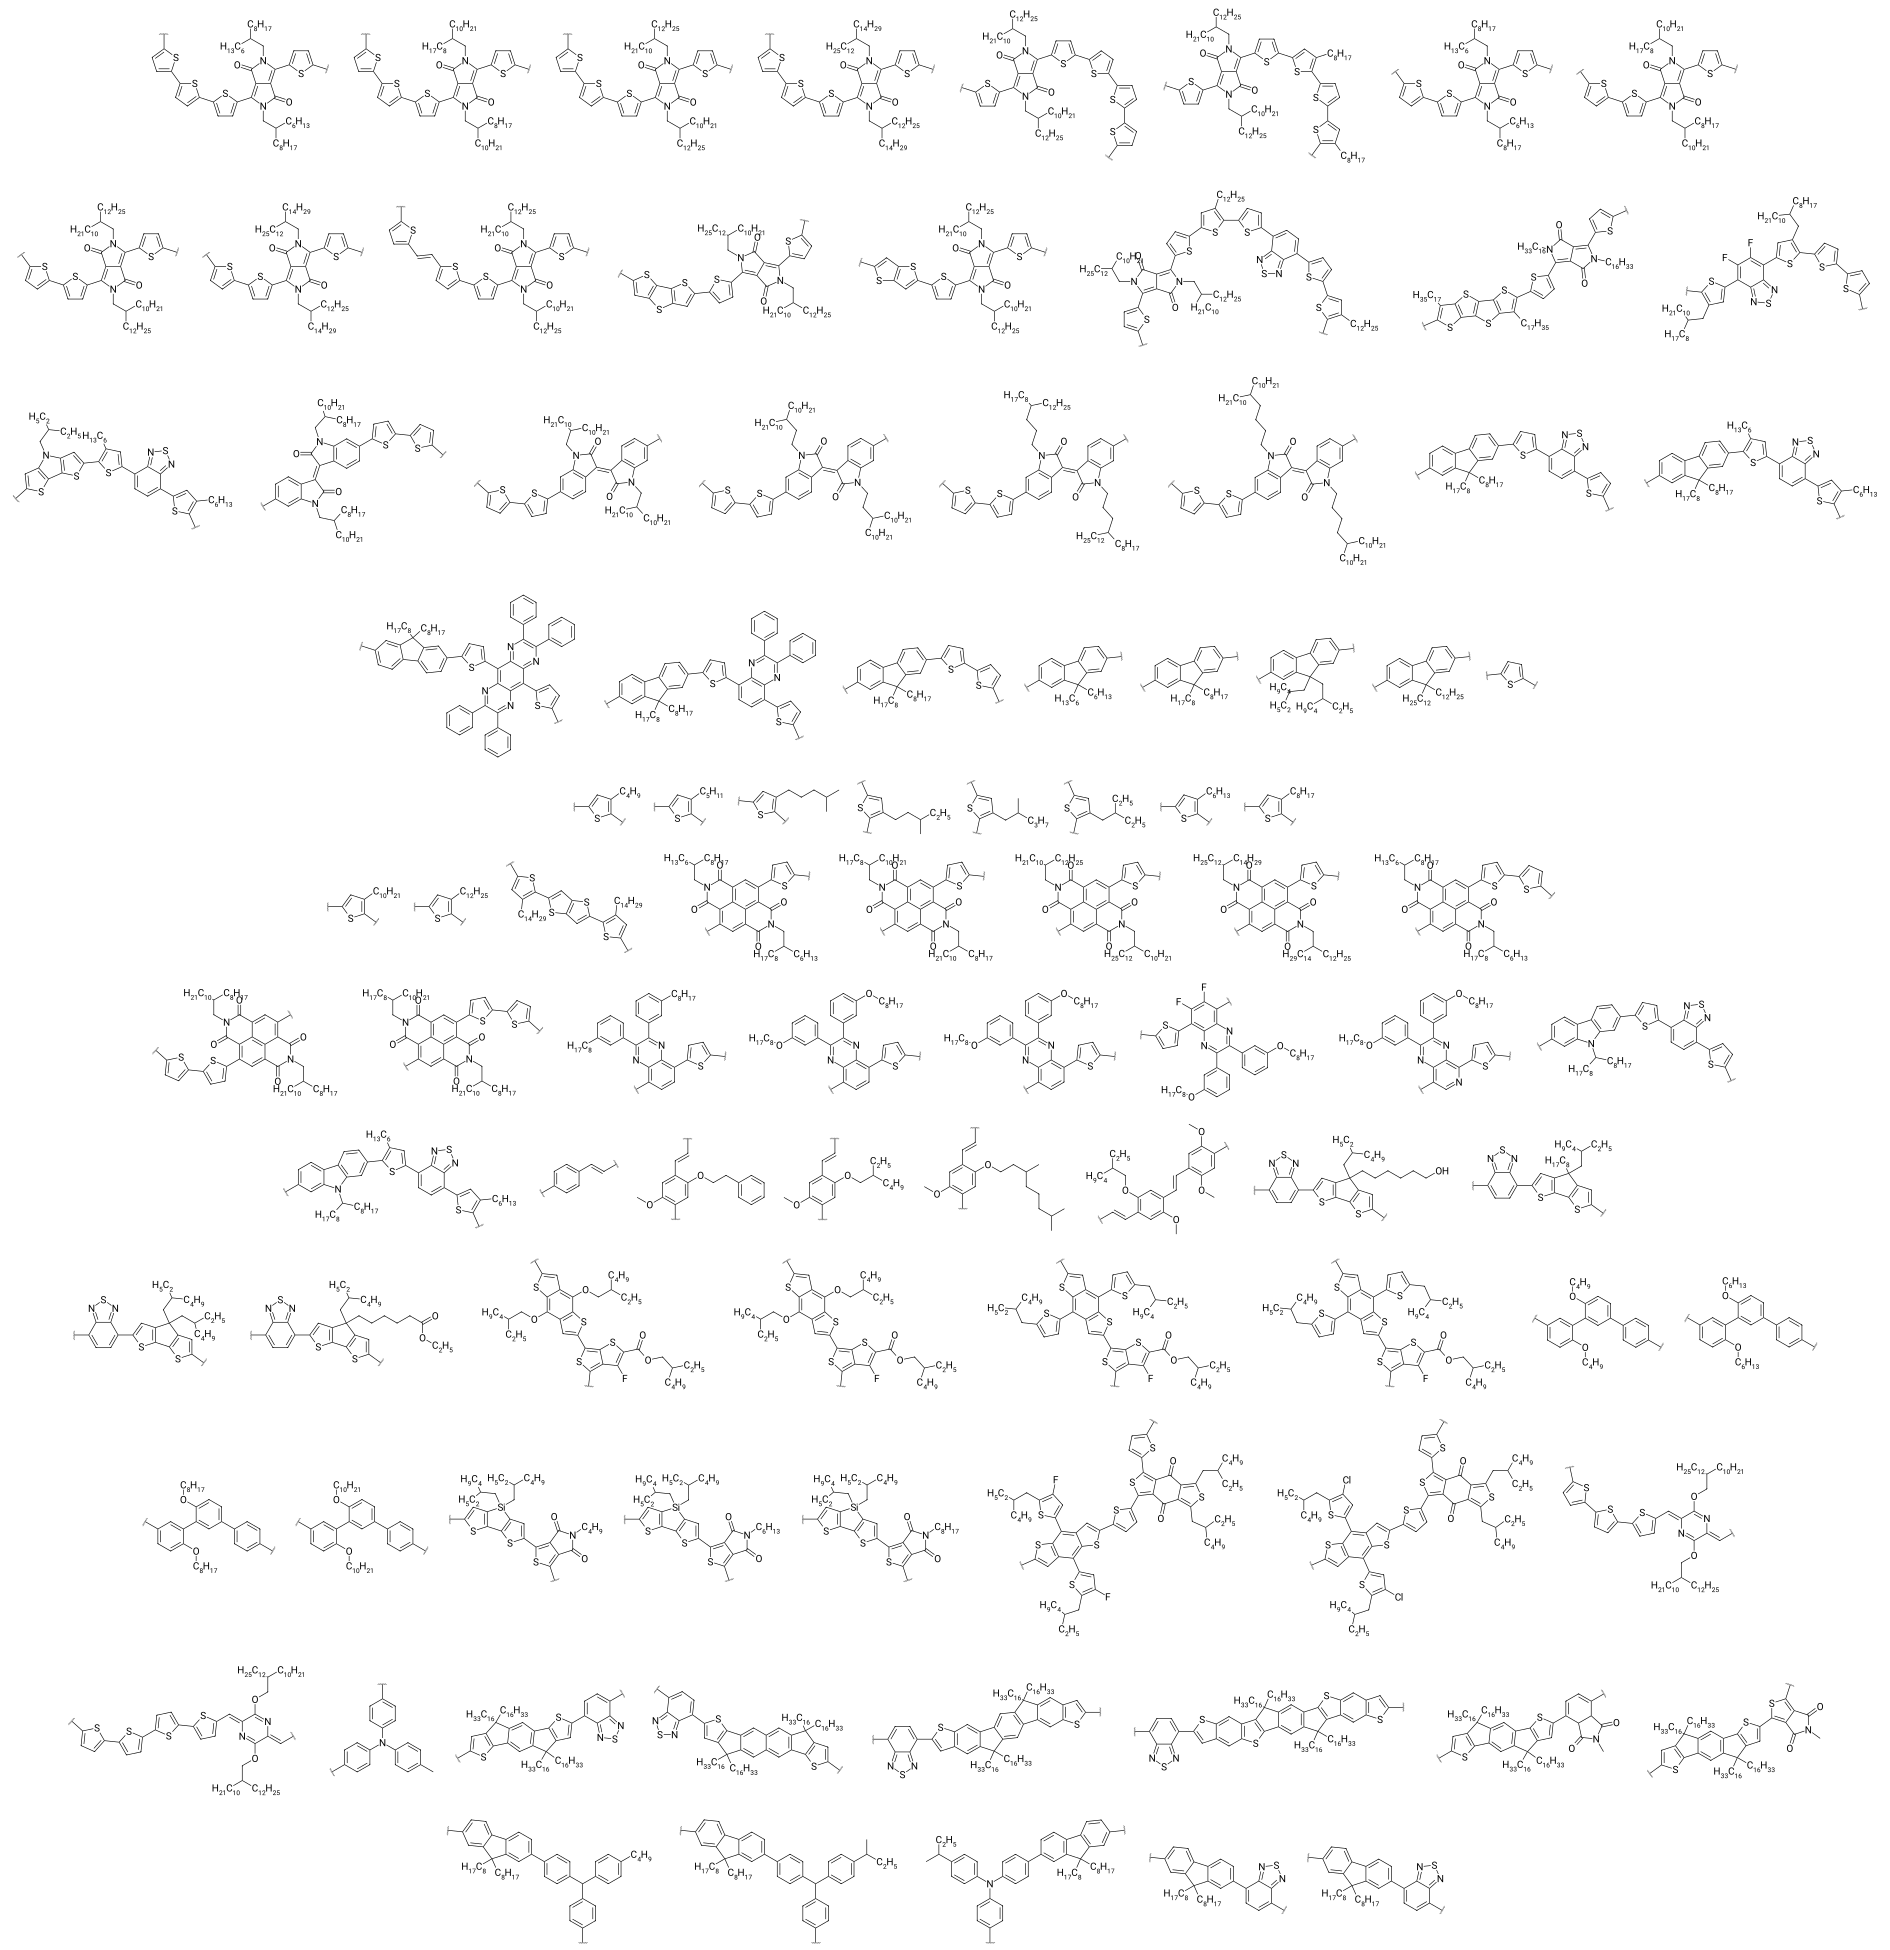

In [151]:
img